# An agent harness, and where the entropy goes

`12` gave the arithmetic back to the model -- v2's prompt unchanged, a calculator it has to call,
a seed that teaches only the calls -- and stopped at 40 steps. This notebook runs that line to
200 steps, finds out why it breaks there, fixes that, and moves the whole loop under qwen-agent,
the framework `membraneclaw-agent` is built on.

Three things were tried, and they came out differently.

| | what | result |
| --- | --- | --- |
| **12 at 200 steps** | `12`'s corrected configuration, run long | peaked at `exact_match` **0.600** (step 125, 599/600 calls exact), then **collapsed**: entropy left its band from step ~100, sampled arithmetic failed from 128, every metric was 0.000 at 200 |
| **13a** | pay the numeric credit on the call that computed it, as the harness scores each call | **abandoned** after three runs: the policy learned to repeat its calls, and twice collapsed |
| **13b** | qwen-agent as the harness, and the entropy bonus taken off the call tokens | harness equivalence **exact** on all 200 dev cases; 200 steps **without collapse**, `exact_match` **0.555** and still rising, held-out `numeric_acc` 0.985-0.997 throughout |

**The prompt did not change anywhere in this notebook.** Every run uses `12`'s: v2 byte for byte,
plus the tool declaration the chat template writes.

What `13b` is and is not evidence for: one seed, one run. The harness change is decoding-neutral
(checked case for case), so against `12` at 200 steps the change that matters is where the entropy
bonus applies -- but a single pair of runs cannot prove that was the cause.

In [1]:
import json, sys
import statistics as st
from pathlib import Path
from collections import Counter
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
RUNS = HERE / "runs"
sys.path.insert(0, str(HERE.resolve()))
sys.path.insert(0, str((HERE / ".." / ".." / "membrane_grpo").resolve()))
import ppo_ac as P
from task.schema import parse_answer
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B", padding_side="left")
KEYS = ("normalized_flow_change_pct", "salt_passage_change_pct", "dp_change_pct")
DEV = {c["id"]: c for c in P.load_cases("dev")}

def jsonl(path):
    return [json.loads(l) for l in open(path) if l.strip()]

def run(name):
    d = RUNS / name
    return (jsonl(d / "eval.jsonl") if (d / "eval.jsonl").exists() else [], jsonl(d / "metrics.jsonl"),
            json.load(open(d / "config.json")))

def resid(r, fit=False):
    a, b = (r.get("value_ev_fit"), r.get("value_ev_position_fit")) if fit else (r.get("value_ev"), r.get("value_ev_position"))
    return None if a is None or b is None else a - b

def by(me, key, width=20):
    return [round(st.mean(r[key] for r in me[i:i + width]), 4) for i in range(0, len(me) - width + 1, width)]

T12 = "ppo-on-tool-seed-warm-200"          # 12's corrected configuration, 200 steps, native harness
T13 = "ppo-tool-qwen-agent-scoped-200"     # 13b: qwen-agent harness + entropy scoped to the answer
ev12, me12, cfg12 = run(T12)
ev13, me13, cfg13 = run(T13)
print("the two 200-step runs differ in:",
      {k: (cfg12.get(k, "-"), v) for k, v in cfg13.items() if cfg12.get(k, "-") != v and k != "metrics"})

/home/bayan/MembraneClaw/experiments/membrane_grpo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


the two 200-step runs differ in: {'critic_warmup': ('-', 0), 'entropy_scope': ('-', 'answer'), 'numeric_stop': ('-', 0.9), 'harness': ('-', 'qwen_agent')}


## 12's configuration, run to 200 steps

`12` stopped at 40 steps, and 40 steps turned out to say nothing about learning: `09`'s own curve is
flat to step ~125. Run long -- same seed, same configuration, `runs/ppo-on-tool-seed-warm-200` --
the tool line learns fast and then destroys itself.

In [2]:
print(f"  {'step':>5}{'exact':>8}{'flags':>8}{'cause':>8}{'numeric':>9}{'calls':>7}{'tokens':>8}")
for r in ev12:
    print(f"  {r['step']:>5}{r['exact_match']:>8.3f}{r['flags_acc']:>8.3f}{r['cause_acc']:>8.3f}"
          f"{r['numeric_acc']:>9.3f}{r['tool_calls_mean']:>7.2f}{r['completion_tokens']:>8.0f}")
print(f"\n  {'steps':>9}{'entropy':>10}{'sampled numeric':>17}{'tokens':>8}{'calls':>7}")
for i in range(0, 200, 20):
    w = me12[i:i + 20]
    print(f"  {i:>4}-{i + 19:<4}{st.mean(r['entropy_proxy'] for r in w):>10.4f}"
          f"{st.mean(r['train_numeric_acc'] for r in w):>17.3f}{st.mean(r['completion_tokens'] for r in w):>8.0f}"
          f"{st.mean(r['tool_calls_mean'] for r in w):>7.2f}")

   step   exact   flags   cause  numeric  calls  tokens
      0   0.065   0.663   0.260    0.997   3.00     335
     25   0.055   0.630   0.335    0.995   3.00     336
     50   0.315   0.842   0.545    0.993   3.00     337
     75   0.415   0.923   0.595    0.990   3.00     338
    100   0.500   0.953   0.675    0.990   3.00     338
    125   0.600   0.953   0.780    0.990   3.00     330
    150   0.430   0.890   0.660    0.883   3.00     325
    175   0.495   0.935   0.815    0.903   3.00     344
    200   0.000   0.000   0.000    0.000   0.00     640

      steps   entropy  sampled numeric  tokens  calls
     0-19      0.0041            1.000     336   3.00
    20-39      0.0030            1.000     336   3.00
    40-59      0.0028            0.985     340   2.99
    60-79      0.0029            0.994     341   3.04
    80-99      0.0018            0.998     338   3.02
   100-119     0.0047            0.983     340   3.02
   120-139     0.0060            0.894     325   3.00
   140-

The order is the finding. The entropy proxy leaves its band first (steps 100-139), the sampled
arithmetic follows (from step 128), the token count runs away last (from 160). Held out, greedy
decoding lags the sampled arithmetic by about 20 steps.

The run left two policies behind -- `adapter-best` at step 125 and `adapter` at step 200 -- and
each was evaluated greedily on dev with every episode kept.

In [3]:
def diagnose(name):
    env = json.load(open(RUNS / "tool" / f"{name}.json"))
    eps = jsonl(RUNS / "tool" / f"{name}.episodes.jsonl")
    same = sum(g == c.get("expression") for e in eps
               for g, c in zip(P.gold_expressions(DEV[e["id"]]["record"]).values(), e["calls"]))
    kinds = Counter()
    for e in eps:
        obj = parse_answer(e["text"]).obj or {}
        for i, k in enumerate(KEYS):
            try:
                tool_ok = abs(float(e["results"][i]) - DEV[e["id"]]["answer"][k]) <= 0.5
            except (IndexError, ValueError):
                tool_ok = False
            v = obj.get(k)
            if not (isinstance(v, (int, float)) and abs(v - DEV[e["id"]]["answer"][k]) <= 0.5):
                kinds["call wrong" if not tool_ok else "copied wrong"] += 1
    o = env["overall"]
    print(f"  {name:22} EM {o['exact_match']:.3f}  numeric {o['numeric_acc']:.3f}  tool use {o['tool_use_rate']:.3f}  "
          f"calls identical to gold {same}/600  numeric misses {dict(kinds)}")
    return eps

best = diagnose("warm200_best125_dev")      # adapter-best: step 125
final = diagnose("warm200_final_dev")       # adapter: step 200
print(f"\n  step 200, every episode: {Counter(e['policy_tokens'] for e in final).most_common(2)} policy tokens")
print("  what it writes:", repr(final[0]["text"][:90]), "...")

  warm200_best125_dev    EM 0.600  numeric 0.990  tool use 1.000  calls identical to gold 599/600  numeric misses {'copied wrong': 6}
  warm200_final_dev      EM 0.000  numeric 0.000  tool use 0.000  calls identical to gold 0/600  numeric misses {'call wrong': 600}

  step 200, every episode: [(640, 200)] policy tokens
  what it writes: '  roundigatequentroundigatequentroundigatequentroundigatequentroundigatequentroundigateque' ...


At step 125 the calls were intact -- 599 of 600 are the gold expression -- and all six numeric
misses were copies. At step 200 the policy no longer calls anything: it writes fragments of the
call template until the budget runs out.

**The reading.** `entropy_coef = 0.005` was set in `05`, on episodes of about 93 tokens that were
all answer. Here an episode is about 336 tokens and 72% of them are the three calls -- tokens the
seed made near-deterministic and on which no reward lands. Averaged over the whole sequence, the
bonus pushes on those tokens with nothing pushing back. `09`'s entropy never left 0.001-0.004 in
400 steps. This is an inference from the timing; `13b` is the test of it.

## 13a -- credit on the calls

The calls are 72% of the policy's tokens and are paid nothing when they are made. `13a` moves each
number's third of `weights.numeric` onto the `</tool_call>` token of the call whose result matched
it -- judged by the harness as the call returns, from an answer key it holds and never shows the
policy -- and **settles** it where the JSON writes the number: the copy's own credit, minus what the
call was already paid. The per-episode total is exactly `score(...).total`; only when the credit
arrives moves. Training checks that live on every step (`call_credit_sum_err`, never above 6e-8).

In [4]:
case = P.load_cases("dev")[0]
ans = case["answer"]
im_end = tok.convert_tokens_to_ids("<|im_end|>")
close = tok.convert_tokens_to_ids("</tool_call>")
enc = lambda t: tok(t, add_special_tokens=False).input_ids
turn1 = enc(P.tool_call_target(case["record"])) + [im_end]
closes = [k for k, t in enumerate(turn1) if t == close]

def check(label, answer_obj, hit_keys):
    body = "Flow x.\n" + (json.dumps(answer_obj, indent=2) if isinstance(answer_obj, dict) else answer_obj)
    ids = turn1 + enc(body) + [im_end]
    text = tok.decode(ids, skip_special_tokens=True)
    hits = {k: closes[i] for i, k in enumerate(KEYS) if k in hit_keys}
    cid, mask = torch.tensor([ids]), torch.ones(1, len(ids))
    plain = P.dense_rewards([text], cid, mask, [case], P.ABLATE, tok, 3.0)
    moved = P.dense_rewards([text], cid, mask, [case], P.ABLATE, tok, 3.0, call_hits=[hits])
    print(f"  {label:32} total {float(plain.sum()):.4f} -> {float(moved.sum()):.4f}   "
          f"on the three calls {[round(float(moved[0, c]), 4) for c in closes]}   "
          f"turn 2 changed by {float((moved - plain)[0, len(turn1):].sum()):+.4f}")

wrong = dict(ans); wrong["normalized_flow_change_pct"] += 5
print(f"one number is worth ABLATE.numeric / 3 = {P.ABLATE.numeric / 3:.4f}\n")
check("calls right, copies right", ans, KEYS)
check("calls right, flow copied wrong", wrong, KEYS)
check("no call matched, copies right", ans, ())
check("calls right, no parsable answer", "no json here", KEYS)

one number is worth ABLATE.numeric / 3 = 0.1167

  calls right, copies right        total 1.0000 -> 1.0000   on the three calls [0.1167, 0.1167, 0.1167]   turn 2 changed by -0.3500
  calls right, flow copied wrong   total 0.8833 -> 0.8833   on the three calls [0.1167, 0.1167, 0.1167]   turn 2 changed by -0.3500
  no call matched, copies right    total 1.0000 -> 1.0000   on the three calls [0.0, 0.0, 0.0]   turn 2 changed by +0.0000
  calls right, no parsable answer  total 0.0000 -> 0.0000   on the three calls [0.1167, 0.1167, 0.1167]   turn 2 changed by -0.3500


Three runs, each one change from the one before, against a bar set before the first: no collapse,
sampled arithmetic >= 0.90 on every step, and `exact_match` after 50 policy steps no lower than
`12`'s 0.315. `G1 - G2` is the return's drop between the start of turn 1 and the start of turn 2 --
what the calls took -- and `V1 - V2` is how much of it the critic has learned.

In [5]:
attempts = (("lam 0.95", "ppo-tool-callcredit-gate40"),
            ("lam 1.0", "ppo-tool-callcredit-lam1-50"),
            ("lam 0.95 + 20 warm-up", "ppo-tool-callcredit-warmup-70"))
for label, name in attempts:
    ev, me, cfg = run(name)
    print(f"{label}  ({name}: lam {cfg['lam']}, critic_warmup {cfg.get('critic_warmup', 0)}, "
          f"{len(me)} of {cfg['steps']} steps logged)")
    print(f"  {'step':>5}{'reward':>8}{'numeric':>9}{'calls':>7}{'tokens':>8}{'G1-G2':>8}{'V1-V2':>8}")
    for r in me[::5] + ([me[-1]] if (len(me) - 1) % 5 else []):
        print(f"  {r['step']:>5}{r['reward_mean']:>8.3f}{r['train_numeric_acc']:>9.3f}{r['tool_calls_mean']:>7.2f}"
              f"{r['completion_tokens']:>8.0f}{r['return_turn1'] - r['return_turn2']:>8.3f}{r['value_turn1'] - r['value_turn2']:>8.3f}")
    if ev:
        print("  held out:", ", ".join(f"step {r['step']} EM {r['exact_match']:.3f} calls {r['tool_calls_mean']:.2f}" for r in ev))
    print()
print(f"what the three calls actually take, all right: {P.ABLATE.numeric:.3f}")
print(f"12's corrected run at step 50 (the bar):  EM {ev12[2]['exact_match']:.3f}")

lam 0.95  (ppo-tool-callcredit-gate40: lam 0.95, critic_warmup 0, 20 of 40 steps logged)
   step  reward  numeric  calls  tokens   G1-G2   V1-V2
      0   0.684    1.000   3.00     333  -0.002   0.000
      5   0.632    1.000   3.00     339   0.064   0.003
     10   0.481    0.875   3.62     403   0.085   0.019
     15   0.066    0.125   5.50     602   0.065   0.007
     19   0.000    0.000   6.00     640   0.067   0.002
  held out: step 0 EM 0.065 calls 3.00, step 10 EM 0.070 calls 3.85

lam 1.0  (ppo-tool-callcredit-lam1-50: lam 1.0, critic_warmup 0, 50 of 50 steps logged)
   step  reward  numeric  calls  tokens   G1-G2   V1-V2
      0   0.684    1.000   3.00     333   0.350   0.000
      5   0.651    1.000   3.00     338   0.350   0.127
     10   0.590    1.000   3.38     367   0.350   0.202
     15   0.571    1.000   3.38     364   0.350   0.253
     20   0.677    1.000   5.25     520   0.350   0.260
     25   0.746    1.000   6.00     578   0.350   0.239
     30   0.686    1.000  

**Abandoned.**

- At `lam = 0.95` the regression target is mostly `V` carried forward, so it never showed the 0.35
  the calls take (`G1 - G2` stayed near 0.07), and neither did the critic. The answer tokens drew
  negative advantages, the policy stopped answering and repeated its calls until the budget ran
  out. Reward was 0.000 from step 16.
- At `lam = 1.0` the target shows the drop exactly and the critic learned most of it (0.31 by step
  49). No collapse -- but the policy doubled its calls within 25 steps (5.8 per episode held out)
  and `exact_match` at step 50 was 0.205.
- With 20 critic-only warm-up steps at `lam = 0.95`, `V` had learned 0.065 of the drop when the
  actor started, and the run collapsed 14 policy steps later.

The repeated calls appear under both targets, so a lagging critic is not the whole story. The
inferred mechanism: while `V` at the start of turn 2 sits above what is left to earn, the
continuation that is actually sampled -- answer now -- keeps drawing negative advantages, and
probability drains to the one that is rarely sampled and so rarely pushed down: call again. It earns
nothing, but nothing penalises it either, until the budget runs out.

## 13b -- qwen-agent as the harness

`membraneclaw-agent` runs qwen-agent 0.0.34 over vLLM with `use_raw_api`: tools reach the chat
template natively and the server parses the calls. `agent_generate` puts the policy under training
behind the same orchestration. `FnCallAgent` owns the loop -- it takes the calls, runs them through
its tool map, appends the results and asks again -- and `PolicyChat`, a raw-API model backend,
stands where vLLM stands: it renders, decodes and parses. What it adds is what a text API cannot
give a trainer: the exact token ids of every turn, kept per episode and never re-rendered. The
agent's `system_message` is v2's own, so qwen-agent adds nothing to the prompt, and `PolicyChat`
refuses to run if the prompt it is handed is not the task's.

Each episode's agent runs in its own thread. `_RoundBatcher` holds every request until each live
episode has either asked for its next turn or finished, then samples the round as one batch on its
own worker thread -- the same rows, order and padding as `tool_generate`. qwen-agent is imported
read-only from the repository's `.venv`; nothing was installed.

**The gate:** the tool seed, greedy on dev, orchestrated by qwen-agent, has to reproduce `12`'s G2
case for case.

In [6]:
a = json.load(open(RUNS / "tool" / "sft_raw_dev.json"))
b = json.load(open(RUNS / "tool" / "sft_raw_dev_qwen_agent.json"))
ea = jsonl(RUNS / "tool" / "sft_raw_dev.episodes.jsonl")
eb = jsonl(RUNS / "tool" / "sft_raw_dev_qwen_agent.episodes.jsonl")
fields = ("text", "calls", "results", "unanswered", "truncated", "policy_tokens", "env_tokens")
print(f"backend: {a['backend']} -> {b['backend']}")
print(f"per-case outcomes identical: {a['overall']['per_case'] == b['overall']['per_case']} "
      f"({len(a['overall']['per_case'])} cases)")
print(f"episodes identical in every field: {sum(all(x[f] == y[f] for f in fields) for x, y in zip(ea, eb))}/{len(ea)}")
print("aggregate keys that differ:", [k for k in a["overall"] if k != "per_case" and a["overall"][k] != b["overall"].get(k)])
print(f"EM {b['overall']['exact_match']:.3f}  numeric {b['overall']['numeric_acc']:.3f}  "
      f"calls {b['overall']['tool_calls_mean']:.2f}  -- G2, reproduced")

backend: hf+calculator -> hf+calculator+qwen_agent
per-case outcomes identical: True (200 cases)
episodes identical in every field: 200/200
aggregate keys that differ: []
EM 0.065  numeric 0.997  calls 3.00  -- G2, reproduced


Identical, not close. From here on the harness is not a variable.

## 13b trained -- 200 steps

`12`'s configuration under qwen-agent, with the entropy bonus summed over the answer turn only
(`--entropy-scope answer`) and still averaged over every active token -- so each answer token is
pushed exactly as hard as in `12`, and the call tokens not at all. `--numeric-stop 0.90` would stop
a run whose sampled arithmetic fails over 10 steps; it never fired.

In [7]:
print(f"  {'step':>5}{'EM 13b':>9}{'EM 12':>8}{'flags':>8}{'cause':>8}{'action':>8}{'numeric 13b':>13}{'numeric 12':>12}")
for x, y in zip(ev13, ev12):
    print(f"  {x['step']:>5}{x['exact_match']:>9.3f}{y['exact_match']:>8.3f}{x['flags_acc']:>8.3f}{x['cause_acc']:>8.3f}"
          f"{x['action_acc']:>8.3f}{x['numeric_acc']:>13.3f}{y['numeric_acc']:>12.3f}")

num = [r["train_numeric_acc"] for r in me13]
means = [st.mean(num[i:i + 10]) for i in range(len(num) - 9)]
late, late_fit = [resid(r) for r in me13[150:] if resid(r) is not None], [resid(r, True) for r in me13[150:] if resid(r, True) is not None]
ref = [resid(r) for r in run("repro-09-current-code-40")[1][20:40] if resid(r) is not None]
e20 = [resid(r) for r in me13[20:40] if resid(r) is not None]
e20f = [resid(r, True) for r in me13[20:40] if resid(r, True) is not None]
rows = [
    ("sampled numeric >= 0.90 on every step", min(num) >= 0.90,
     f"min {min(num):.3f}; below on steps {[r['step'] for r in me13 if r['train_numeric_acc'] < 0.9]}"),
    ("sampled numeric, 10-step mean >= 0.90 (the stop)", min(means) >= 0.90, f"lowest {min(means):.3f}; the stop never fired"),
    ("held-out numeric >= 0.95 at every point", min(r["numeric_acc"] for r in ev13) >= 0.95,
     f"min {min(r['numeric_acc'] for r in ev13):.3f}"),
    ("tool use >= 0.95 at every point", min(r["tool_use_rate"] for r in ev13) >= 0.95,
     f"min {min(r['tool_use_rate'] for r in ev13):.3f}"),
    ("critic - clock over 20-39 >= -0.001 (set before 13)", st.median(e20) >= -0.001,
     f"{st.median(e20):+.4f}, ahead {sum(x > 0 for x in e20)}/{len(e20)}"),
    ("critic fit - clock fit over 20-39 > 0 (set before 13)", st.median(e20f) > 0, f"{st.median(e20f):+.4f}"),
    ("critic - clock over 150-199 >= 09 today (chosen after)", st.median(late) >= st.median(ref),
     f"{st.median(late):+.4f}, ahead {sum(x > 0 for x in late)}/{len(late)}  (09's command today {st.median(ref):+.4f})"),
    ("critic fit - clock fit over 150-199 > 0 (chosen after)", st.median(late_fit) > 0, f"{st.median(late_fit):+.4f}"),
    ("no collapse to step 200", ev13[-1]["exact_match"] > 0 and max(r["truncated_rate"] for r in me13) < 0.5,
     f"EM {ev13[-1]['exact_match']:.3f} at 200; truncation never above {max(r['truncated_rate'] for r in me13):.3f}"),
]
print()
for name, ok, detail in rows:
    print(f"  {'PASS' if ok else 'FAIL'}  {name:56} {detail}")

   step   EM 13b   EM 12   flags   cause  action  numeric 13b  numeric 12
      0    0.065   0.065   0.663   0.260   0.215        0.997       0.997
     25    0.190   0.055   0.720   0.475   0.380        0.997       0.995
     50    0.195   0.315   0.853   0.375   0.330        0.997       0.993
     75    0.290   0.415   0.880   0.450   0.385        0.985       0.990
    100    0.320   0.500   0.948   0.490   0.410        0.992       0.990
    125    0.415   0.600   0.938   0.560   0.480        0.988       0.990
    150    0.465   0.430   0.947   0.570   0.510        0.985       0.883
    175    0.545   0.495   0.965   0.660   0.580        0.990       0.903
    200    0.555   0.000   0.960   0.710   0.620        0.988       0.000

  FAIL  sampled numeric >= 0.90 on every step                    min 0.875; below on steps [135, 151, 191]
  PASS  sampled numeric, 10-step mean >= 0.90 (the stop)         lowest 0.983; the stop never fired
  PASS  held-out numeric >= 0.95 at every point     

In [8]:
print(f"  {'steps':>9}{'entropy 12':>12}{'entropy 13b':>13}{'calls 13b':>11}{'answer 13b':>12}{'critic-clock 13b':>18}")
for i in range(0, 200, 20):
    w = me13[i:i + 20]
    res = [resid(r) for r in w if resid(r) is not None]
    print(f"  {i:>4}-{i + 19:<4}{st.mean(r['entropy_proxy'] for r in me12[i:i + 20]):>12.4f}"
          f"{st.mean(r['entropy_proxy'] for r in w):>13.4f}{st.mean(r['entropy_proxy_calls'] for r in w):>11.5f}"
          f"{st.mean(r['entropy_proxy_answer'] for r in w):>12.4f}{st.median(res):>+18.4f}")

      steps  entropy 12  entropy 13b  calls 13b  answer 13b  critic-clock 13b
     0-19        0.0041       0.0035    0.00003      0.0068           -0.0472
    20-39        0.0030       0.0032    0.00003      0.0093           -0.0077
    40-59        0.0028       0.0031    0.00013      0.0094           +0.0016
    60-79        0.0029       0.0024    0.00040      0.0059           +0.0045
    80-99        0.0018       0.0028    0.00014      0.0070           +0.0081
   100-119       0.0047       0.0042    0.00071      0.0120           +0.0110
   120-139       0.0060       0.0041    0.00099      0.0099           +0.0121
   140-159       0.0139       0.0047    0.00122      0.0117           +0.0154
   160-179       0.0481       0.0027    0.00066      0.0077           +0.0257
   180-199       2.1398       0.0030    0.00071      0.0077           +0.0316


**It did not collapse.** At steps 150 and 200, where `12` read 0.883 and 0.000 held-out numeric,
this run reads 0.985 and 0.988, and `exact_match` keeps climbing to 0.555. The entropy proxy stays
at or below 0.0047 through step 199; `12`'s reached 2.14.

**The call tokens still drifted, a little.** Their entropy rose from 3e-5 to 1.2e-3 by steps
140-159 with no bonus on them, then fell back to 7e-4. The bonus was not the only force on them --
the LoRA weights are shared, so pushing the answer moves the calls as well -- but without it the
drift stayed three orders of magnitude below where `12` broke.

**The gates, as set.** The sampled arithmetic dipped below 0.90 on three single steps (0.875 each
time, 3 of 24 numbers), so the every-step bar fails as written; the 10-step stop never came
close. The critic missed the bar set before `13` ran -- steps 20-39 are -0.008, and
its in-sample fit is below the clock too -- and was ahead of
the clock on every step from 150 on, by +0.026, the best critic in the series. That late window is a
bar chosen after seeing the run, and the table says so.

**Against 12's best.** `12` reached 0.600 at step 125 before it broke; this run is at 0.555 at 200
and still rising (`cause_acc` 0.660 -> 0.710, `action_acc` 0.580 -> 0.620). The severe action is
still never emitted, which caps `exact_match` at 163/200 = 0.815.

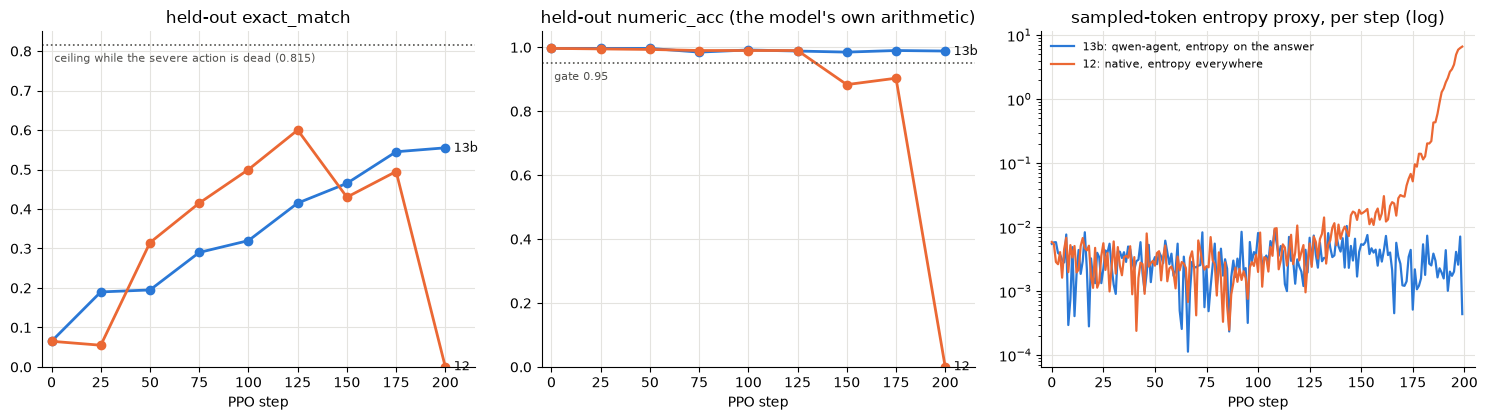

In [9]:
SERIES = ("#2a78d6", "#eb6834")                  # reference palette, slots 1-2, in order
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
RUNS_PLOTTED = (("13b: qwen-agent, entropy on the answer", ev13, me13), ("12: native, entropy everywhere", ev12, me12))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for color, (label, ev, me) in zip(SERIES, RUNS_PLOTTED):
    steps = [r["step"] for r in ev]
    axes[0].plot(steps, [r["exact_match"] for r in ev], "-o", color=color, lw=2, ms=6, label=label)
    axes[1].plot(steps, [r["numeric_acc"] for r in ev], "-o", color=color, lw=2, ms=6, label=label)
    axes[2].plot([r["step"] for r in me], [max(r["entropy_proxy"], 1e-4) for r in me], color=color, lw=1.6, label=label)
for ax in axes[:2]:
    ax.annotate("13b", (200, ev13[-1][("exact_match", "numeric_acc")[list(axes).index(ax)]]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
    ax.annotate("12", (200, ev12[-1][("exact_match", "numeric_acc")[list(axes).index(ax)]]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
axes[0].set(title="held-out exact_match", xlabel="PPO step", ylim=(0, 0.85), xlim=(-5, 215))
axes[0].axhline(163 / 200, color=MUTED, ls=":", lw=1.2)
axes[0].annotate("ceiling while the severe action is dead (0.815)", (0, 163 / 200), xytext=(2, -12),
                 textcoords="offset points", fontsize=8, color=MUTED)
axes[1].set(title="held-out numeric_acc (the model's own arithmetic)", xlabel="PPO step", ylim=(0, 1.05), xlim=(-5, 215))
axes[1].axhline(0.95, color=MUTED, ls=":", lw=1.2)
axes[1].annotate("gate 0.95", (0, 0.95), xytext=(2, -12), textcoords="offset points", fontsize=8, color=MUTED)
axes[2].set(title="sampled-token entropy proxy, per step (log)", xlabel="PPO step", yscale="log", xlim=(-5, 205))
axes[2].legend(loc="upper left", fontsize=8, frameon=False)
for ax in axes:
    ax.grid(color=GRID, lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RUNS / "qwen_agent_scoped_200.png", dpi=110)
plt.show()

### Three restarts, recorded

- The first attempt died in its step-0 evaluation with `CUDA error: unknown error`, logged together
  with WSL's dxg driver reporting failed ioctls. Rounds were then sampled on whichever agent thread
  completed them; `_RoundBatcher` now samples on one worker thread, and the error has not recurred.
- The second scoped the bonus and also divided it by the answer tokens alone -- a 3.7x stronger push
  on them, and a second variable. Answer entropy doubled in 25 steps; it was stopped at step 50
  (`runs/ppo-tool-qwen-agent-scoped-answernorm-stopped-at-50`).
- The third was at step 34 when WSL shut down at 19:48 and took it with it
  (`runs/ppo-tool-qwen-agent-scoped-killed-by-wsl-at-34`). Runs now save `<run>/last/` at every
  evaluation, so `--resume-from` can pick one up.

## Where the line stands

The arithmetic belongs to the model -- through a tool, on an unchanged prompt -- and under qwen-agent
it holds for 200 steps. Still open:

- **a second seed for 13b.** The entropy explanation rests on one pair of runs.
- **a per-turn discount**, planned for `13` and not run: with `13a` abandoned it belongs on top of
  `13b`.
- **past 200 steps.** The curve had not flattened; `adapter-best` (step 200) is kept for a resume.
- **the severe action**, never emitted, which caps `exact_match` at 0.815 -- `10`'s dead label,
  deferred.